In [1]:
# === Standard Libraries ===
import os
import numpy as np
import pandas as pd
import scipy
from scipy.stats import median_abs_deviation
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from tqdm import tqdm
import pyBigWig as pbw

# === PyTorch ===
import torch
from torch.utils.data import DataLoader

# === Tangermeme
# from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
# from tangermeme.plot import plot_logo
# from tangermeme.predict import predict
# from tangermeme.product import apply_pairwise
# from tangermeme.io import read_meme
# from tangermeme.annotate import annotate_seqlets, count_annotations
# from tangermeme.seqlet import recursive_seqlets, tfmodisco_seqlets



In [2]:
%run /home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/Common.ipynb
params.read("/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini")

['/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini']

In [3]:
import anndata as ad
import pandas as pd
import numpy as np
from genome_tools.data.anndata import read_zarr_backed
from genome_tools import GenomicInterval, VariantInterval, df_to_variant_intervals
from genome_tools.data.extractors import FastaExtractor, TabixExtractor

from vinson.utils.sequence_utils import one_hot_encode, get_iupac_char_from_alleles
from vinson.utils.helpers import replace_at
import logging

from vinson.utils.data_formatting import extract_data_from_h5
from vinson.from_config import read_configs

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# === Custom Fonts for Matplotlib ===
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]



In [4]:
import os
import sys
import random
import numpy as np
import anndata as ad
from argparse import ArgumentParser


import torch
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)
from vinson.from_config import (
    read_configs,
    variant_model_from_config,
    datamodule_from_config,
    dhs_model_from_config


)
from vinson.run import (
    set_global_seed,
    set_worker_seed,
    init_multigpu_trainer,
    fit_model,
)

torch.set_float32_matmul_precision('high')

In [ ]:
var_config_path = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_12_elastic_bohr/run_config.yaml'
var_checkpoint = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_12_elastic_bohr/checkpoints/last.ckpt'

# reg_config_path = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_final_rerun/legnet_embed.new_cluster.one_cycle_LR.yaml'
# reg_checkpoint = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_final_rerun/check_last_epoch=2.ckpt'
reg_checkpoint = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_final_rerun.w_mlp_cell_embed.drop0/clear_reb_drop0_best_epoch=2.ckpt'
reg_config_path = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/NOV03_final_rerun.w_mlp_cell_embed.drop0/legnet_embed.new_cluster.one_cycle_LR.yaml'

In [26]:
variant_file = '/net/seq/data2/projects/mbrannon/vinson/3_9_dataset_35totalcount_3epoch.h5ad'
genotype_file = '/home/mbrannon/genotype_no_multiallelic.tsv.gz'
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"

In [11]:
var_config = read_configs(var_config_path)
reg_config = read_configs(reg_config_path)
variant_model = variant_model_from_config(var_config, checkpoint_path=var_checkpoint).eval()
reg_model = dhs_model_from_config(reg_config, checkpoint_path=reg_checkpoint).eval()

device = torch.device("cpu")
variant_model.to(device)
reg_model.to(device)


SequenceEmbedModel(
  (trunk_model): LegNetTrunkEmbed(
    (stem): StemConv(
      (convs_list): ModuleList(
        (0): Conv1d(4, 24, kernel_size=(6,), stride=(1,), padding=same, bias=False)
        (1): Conv1d(4, 24, kernel_size=(9,), stride=(1,), padding=same, bias=False)
        (2): Conv1d(4, 24, kernel_size=(12,), stride=(1,), padding=same, bias=False)
        (3): Conv1d(4, 24, kernel_size=(15,), stride=(1,), padding=same, bias=False)
      )
    )
    (blocks_dict): ModuleDict(
      (blc0): Sequential(
        (0): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): ResidualConcat(
          (fn): EffBlock(
            (block): Sequential(
              (0): Conv1d(96, 384, kernel_size=(1,), stride=(1,), padding=same, bias=False)
              (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU()
              (3): Conv1d(384, 384, kernel_size=(9,), stride=(1

In [12]:
from vinson.utils.data_formatting import extract_variant_data_from_anndata
from vinson.datasets.variant import VariantEmbedDataset


## reg vs variant results test

In [27]:
dhs_split = "val"
full_adata = ad.read_h5ad(variant_file)
adata_val = full_adata[
    :,
    full_adata.varm["split_data"] == dhs_split,
]

In [16]:

def to_tensor(x, device):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.to(device)
    return torch.as_tensor(x, device=device)

def predict_regular(batch, model, device):
    seq_ref = to_tensor(batch["ohe_seq_ref"], device)
    seq_alt = to_tensor(batch["ohe_seq_alt"], device)
    embed   = to_tensor(batch.get("embed"), device)

    with torch.no_grad():
        y_ref = model(
            seq=seq_ref,
            embedding=embed,
        )

        y_alt = model(
            seq=seq_alt,
            embedding=embed,
        )

    return (
        y_ref.squeeze(-1).cpu().numpy(),
        y_alt.squeeze(-1).cpu().numpy(),
    )

def predict_variant(batch, model, device):
    seq_ref = to_tensor(batch["ohe_seq_ref"], device)
    seq_alt = to_tensor(batch["ohe_seq_alt"], device)
    embed   = to_tensor(batch.get("embed"), device)

    with torch.no_grad():
        y = model(
            seq_ref=seq_ref,
            seq_alt=seq_alt,
            embed=embed,
        )

    return y.squeeze(-1).cpu().numpy()


In [28]:
all_data = extract_variant_data_from_anndata(full_adata, "epoch_1")


In [37]:
dataset = VariantEmbedDataset(
    data=all_data,
    fasta_file=fasta_file,
    genotype_file=genotype_file
)

val_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

In [38]:
from tqdm import tqdm

model = variant_model
model.eval()


VariantEmbedModel(
  (trunk_model): LegNetTrunkEmbed(
    (stem): StemConv(
      (convs_list): ModuleList(
        (0): Conv1d(4, 24, kernel_size=(6,), stride=(1,), padding=same, bias=False)
        (1): Conv1d(4, 24, kernel_size=(9,), stride=(1,), padding=same, bias=False)
        (2): Conv1d(4, 24, kernel_size=(12,), stride=(1,), padding=same, bias=False)
        (3): Conv1d(4, 24, kernel_size=(15,), stride=(1,), padding=same, bias=False)
      )
    )
    (blocks_dict): ModuleDict(
      (blc0): Sequential(
        (0): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): ResidualConcat(
          (fn): EffBlock(
            (block): Sequential(
              (0): Conv1d(96, 384, kernel_size=(1,), stride=(1,), padding=same, bias=False)
              (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU()
              (3): Conv1d(384, 384, kernel_size=(9,), stride=(1,

In [39]:
from tqdm import tqdm
#just run 10 epoch for now
all_preds = []
all_targets = []
n=0
model = variant_model
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Running validation"):
        n+=1
        seq_ref = batch["ohe_seq_ref"].to(device)
        seq_alt = batch["ohe_seq_alt"].to(device)
        embed   = batch["embed"].to(device)

        targets = batch["lfc"].to(device)

        outputs = model(
            seq_ref=seq_ref,
            seq_alt=seq_alt,
            embed=embed,
        )

        preds = outputs.squeeze(-1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        if n==1800:
            break


Running validation:  21%|██        | 1799/8621 [32:00<2:01:23,  1.07s/it]


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)


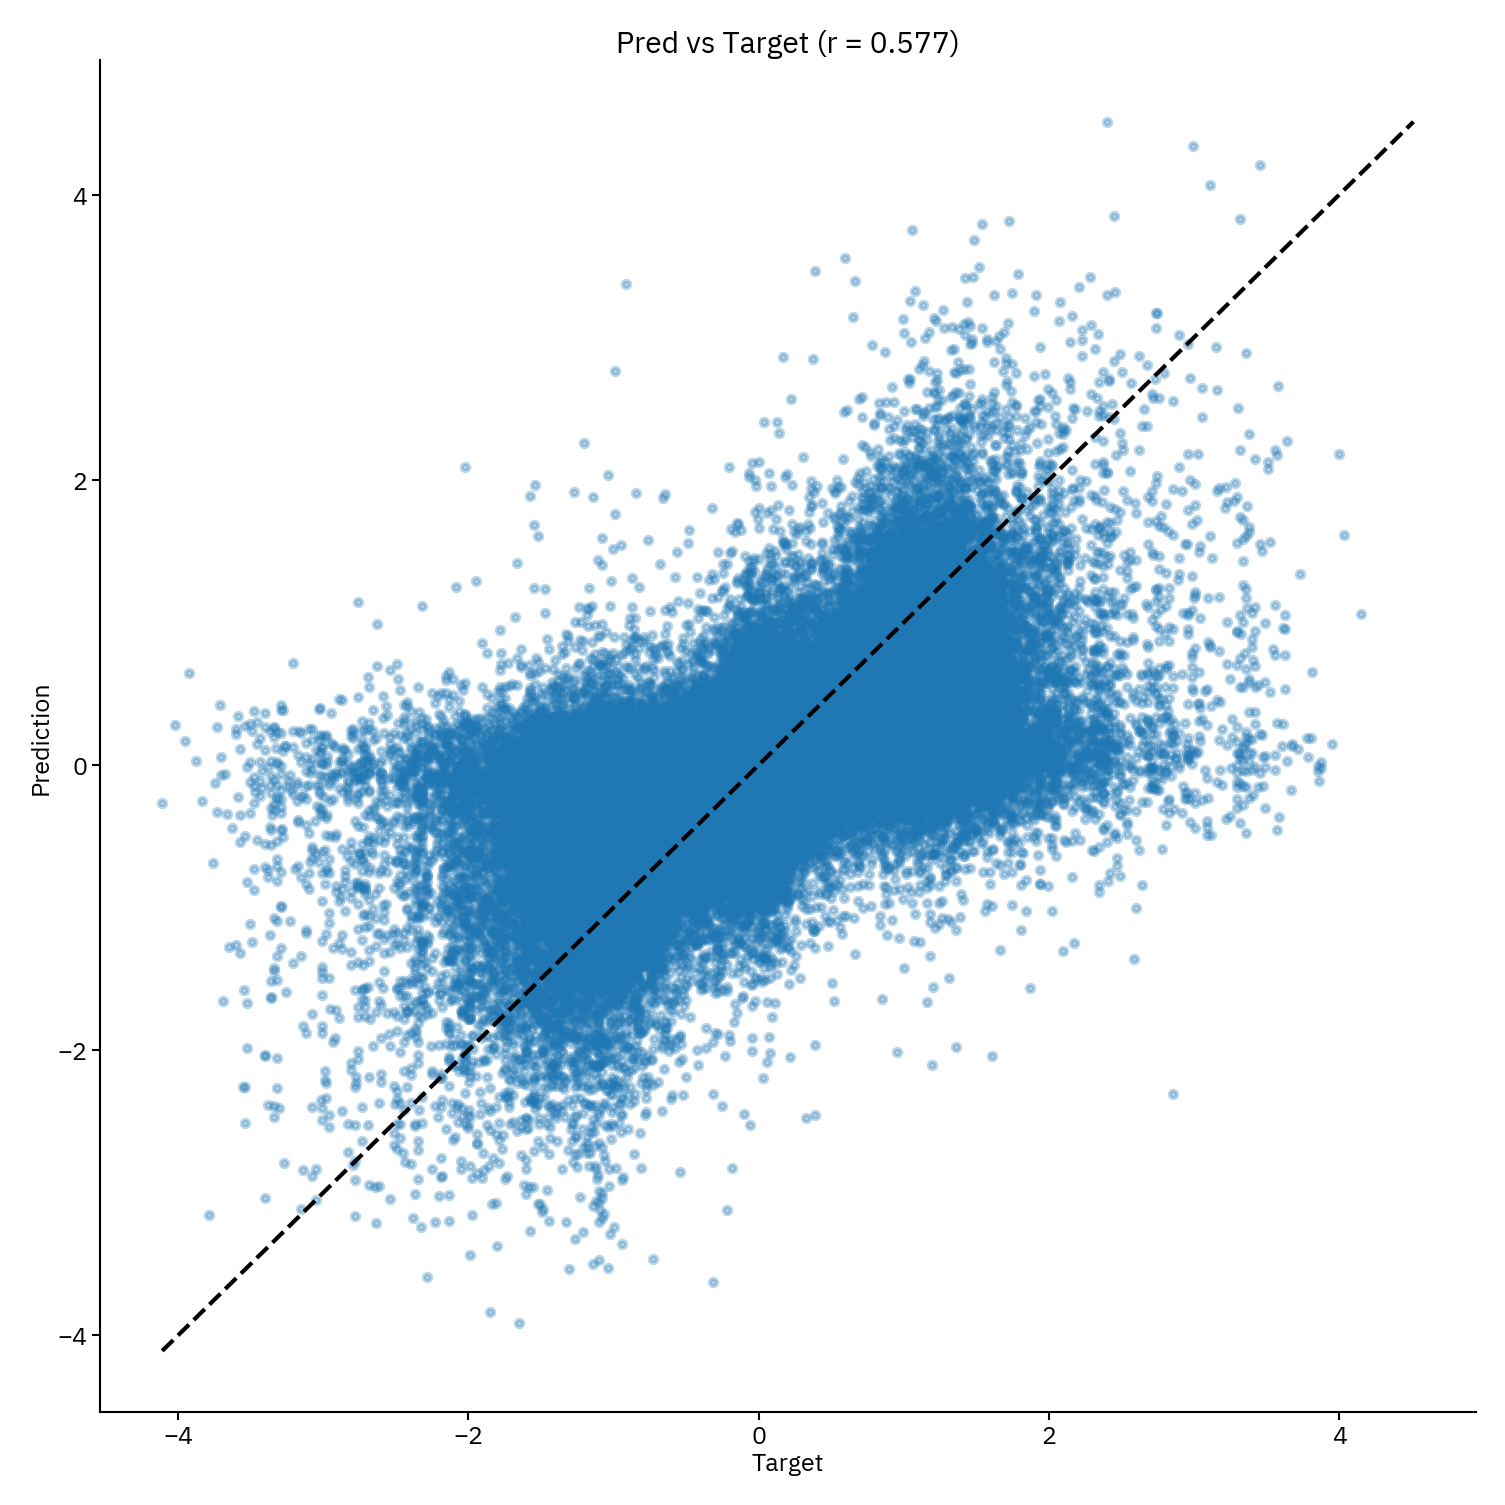

In [41]:
plt.figure(figsize=(5, 5))
plt.scatter(all_targets, all_preds, s=3, alpha=0.3)

# diagonal line
lims = [
    min(all_targets.min(), all_preds.min()),
    max(all_targets.max(), all_preds.max()),
]
plt.plot(lims, lims, 'k--', linewidth=1)

r, _ = pearsonr(all_targets, all_preds)

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title(f"Pred vs Target (r = {r:.3f})")
plt.tight_layout()
plt.show()


## copy sasha

In [16]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix, lil_matrix, save_npz, load_npz

In [62]:
meta = pd.read_table(
    '/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/metadata.clustered.tsv',
    usecols=['sample_id', 'extended_annotation']
).drop_duplicates()

In [ ]:
#genotype_file = '/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz'
genotype_file = '/net/seq/data2/projects/mbrannon/all_phased.no_ambiguous.sorted.with_header.bgz'
fasta_file = '/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa'

In [45]:
model = variant_model
model.eval()

VariantEmbedModel(
  (trunk_model): LegNetTrunkEmbed(
    (stem): StemConv(
      (convs_list): ModuleList(
        (0): Conv1d(4, 24, kernel_size=(6,), stride=(1,), padding=same, bias=False)
        (1): Conv1d(4, 24, kernel_size=(9,), stride=(1,), padding=same, bias=False)
        (2): Conv1d(4, 24, kernel_size=(12,), stride=(1,), padding=same, bias=False)
        (3): Conv1d(4, 24, kernel_size=(15,), stride=(1,), padding=same, bias=False)
      )
    )
    (blocks_dict): ModuleDict(
      (blc0): Sequential(
        (0): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): ResidualConcat(
          (fn): EffBlock(
            (block): Sequential(
              (0): Conv1d(96, 384, kernel_size=(1,), stride=(1,), padding=same, bias=False)
              (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU()
              (3): Conv1d(384, 384, kernel_size=(9,), stride=(1,

In [17]:
variants = pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')

In [52]:
variants = used_results

In [53]:
variants['group_id']

0              B-cell
1          Fibroblast
2          Fibroblast
3          Macrophage
4                Lung
              ...    
9320627          Lung
9320628     Carcinoma
9320629          Lung
9320630    Epithelium
9320631           CML
Name: group_id, Length: 9320632, dtype: object

In [19]:
variants.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'badgroup',
       'indiv_id', 'total_counts', 'variant_id', 'group_id', 'group_es',
       'group_es_std', 'indivs_count', 'samples_count', 'p_differential',
       'cell_selective', 'n_groups', 'group_es_var', 'mean_group_mse',
       'es_combined', 'overall_imbalanced', 'logit_es_combined', 'fdr_group',
       'signif_max_es', 'signif_min_es', 'concordant', 'discordant',
       'logit_group_es', 'category', 'core_category', 'med_num_samples',
       'full_group_std', 'z', 'signif_z', 'max_z', 'min_z', 'min_abs_z',
       'discordance_score', 'max_z_score', 

In [34]:
import anndata as ad
from argparse import ArgumentParser

# from dnase_legnet.utils import AUC_callback,Pearsonr_callback, generate_name, read_configs_siamese

import torch
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)

from vinson.utils.helpers import save_config, generate_run_name
from vinson.run import set_global_seed,set_worker_seed,init_multigpu_trainer,fit_model
from vinson.from_config import read_configs,datamodule_from_config,variant_model_from_config

indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')


In [216]:
variants = pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')

In [22]:
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')

In [238]:
#filter variants by rsid then convert to anndata
rsid = 'rs75326860'
var_oi=variants[variants['ID']==rsid]

In [259]:
var_oi = var_oi.query('coverage >= 20')

In [260]:
var_df = var_oi.drop_duplicates('variant_id').set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]

In [261]:
train_var_adata = ad.AnnData(X=None, var=var_df, obs=adata.obs)
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 1
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 'treatm

In [262]:

row_idx = var_oi['sample_id'].map(lambda x: train_var_adata.obs.index.get_loc(x))
col_idx = var_oi['variant_id'].map(lambda x: train_var_adata.var.index.get_loc(x))

In [263]:
var_oi.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'badgroup',
       'indiv_id', 'total_counts', 'variant_id', 'group_id', 'group_es',
       'group_es_std', 'indivs_count', 'samples_count', 'p_differential',
       'cell_selective', 'n_groups', 'group_es_var', 'mean_group_mse',
       'es_combined', 'overall_imbalanced', 'logit_es_combined', 'fdr_group',
       'signif_max_es', 'signif_min_es', 'concordant', 'discordant',
       'logit_group_es', 'category', 'core_category', 'med_num_samples',
       'full_group_std', 'z', 'signif_z', 'max_z', 'min_z', 'min_abs_z',
       'discordance_score', 'max_z_score', 

In [264]:
import numpy as np

# Numeric columns
layer_cols_numeric = [
    'ref_counts', 'alt_counts',  'BAD', 'SNP_count', 'coverage', 'w', 'es','z',
    'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample', 'inverse_mse',
    'total_counts', 'group_es', 'group_es_std', 'indivs_count', 'samples_count',
    'p_differential', 'n_groups', 'group_es_var', 'mean_group_mse',
    'es_combined', 'logit_es_combined', 'fdr_group',
    'signif_max_es', 'signif_min_es', 'logit_group_es', 'full_group_std', 'discordance_score',
    'delta_es', 'delta_es_q', 'delta_logit_es'
]

# String columns
layer_cols_strings = ['core_category', 'category']

# Convert numeric columns to float
var_oi[layer_cols_numeric] = var_oi[layer_cols_numeric].astype(float)


In [265]:
var_oi

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,max_es_group_std,max_es,min_es_group_std,min_es,delta_es,delta_es_std,delta_es_q,delta_logit_es,med_std_group,abs_logit_group_es
20772643,chr17,82876818,82876819,rs75326860,C,T,0.0,21.0,AG80288,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,0.939743
20772645,chr17,82876818,82876819,rs75326860,C,T,1.0,25.0,AG80236,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,0.939743
20772646,chr17,82876818,82876819,rs75326860,C,T,10.0,11.0,AG58823,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,0.235796
20772647,chr17,82876818,82876819,rs75326860,C,T,10.0,12.0,AG80006,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,NaN
20772648,chr17,82876818,82876819,rs75326860,C,T,10.0,13.0,AG80004,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20772809,chr17,82876818,82876819,rs75326860,C,T,9.0,11.0,AG79971,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,0.240663
20772810,chr17,82876818,82876819,rs75326860,C,T,9.0,13.0,AG58727,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,0.091379
20772811,chr17,82876818,82876819,rs75326860,C,T,9.0,14.0,AG72815,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,0.086579
20772812,chr17,82876818,82876819,rs75326860,C,T,9.0,16.0,AG80738,0.086336,...,0.311202,0.541407,0.378732,0.34022,0.201186,0.490188,0.410427,1.17554,0.099754,0.939743


In [266]:
import scipy.sparse as sp

for col in layer_cols_numeric:
    data = sp.coo_matrix(
        (var_oi[col].values, (row_idx, col_idx)),
        shape=train_var_adata.shape
    ).tocsr()
    train_var_adata.layers[col] = data

# Add string columns to var (per-variant metadata)
for col in ['core_category', 'category']:
    # Use the first occurrence per variant_id
    train_var_adata.var[col] = var_oi.groupby('variant_id')[col].first().reindex(train_var_adata.var.index)

In [267]:
train_var_adata.obsm['indiv_id'] = train_var_adata.obs_names.map(indiv_id_mapping['indiv_id']).fillna('').to_numpy().astype(str)

In [268]:
for layer in list(train_var_adata.layers):
    train_var_adata.layers[f"{layer}.epoch_1"] = train_var_adata.layers[layer]
    del train_var_adata.layers[layer]

In [269]:
train_var_adata.obsm['motif_embeddings'] = adata.obsm['motif_embeddings'].loc[train_var_adata.obs_names]

In [270]:
#save
# train_var_adata.write_h5ad("/home/mbrannon/tmp/3_2_trainann.h5ad")


In [271]:
# test = non_ag.query('coverage >= 35')

In [272]:
# variants[variants['ID']=='rs75326860']

In [273]:
from torch.utils.data import DataLoader
from vinson.utils.data_formatting.readers import extract_variant_data_from_anndata

data = extract_variant_data_from_anndata(train_var_adata, "epoch_1")

In [274]:
 data

VinsonData with keys: ['chrom', 'pos', 'ref', 'alt', 'sample_id', 'ref_counts', 'total_counts', 'BAD', 'logit_es', 'indiv_id']. Encoded columns: ['sample_id', 'chrom', 'ref', 'alt', 'indiv_id'].

In [275]:
# Check how many samples have non-zero logit_es
logit_layer = train_var_adata.layers['logit_es.epoch_1']
nonzero_count = (logit_layer != 0).sum()
print(nonzero_count)  # should be ~80

111


In [276]:
# 4️⃣ Wrap in VariantEmbedDataset
from vinson.datasets.variant import VariantEmbedDataset

dataset = VariantEmbedDataset(
    data=data,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
)

# 5️⃣ Create DataLoader
loader = DataLoader(dataset, batch_size=128, shuffle=False)

# ✅ Now loader contains all samples for rs10151094 with per-sample measurements

In [277]:
model.eval()
predictions = []
lfc_all = []

with torch.no_grad():
    for batch in loader:
        X_seq_ref, X_seq_alt, X_embed, ref_counts, total_counts, bad_score, lfc = (
            batch["ohe_seq_ref"],
            batch["ohe_seq_alt"],
            batch["embed"],
            batch["ref_counts"],
            batch["total_counts"],
            batch["bad_score"],
            batch["lfc"],
        )
        # Predict example with model
        y = model(X_seq_ref, X_seq_alt, X_embed).squeeze()
        
        predictions.append(y)
        lfc_all.append(lfc)

predictions = torch.cat(predictions, dim=0)
actual = torch.cat(lfc_all, dim=0)

In [278]:
adata_rs =  train_var_adata
# 1️⃣ Get the nonzero indices from any per-sample layer (here ref_counts)
layer = adata_rs.layers["ref_counts.epoch_1"]
row_idx, col_idx = layer.nonzero()

# 2️⃣ Build v_df with predictions and actuals
v_df = pd.DataFrame({
    "predicted_es": predictions.cpu().numpy(),
    "logit_es": actual.cpu().numpy(),
    # map row/col indices back to obs/var
    "sample_id": adata_rs.obs_names[row_idx],               # rows = samples
    "group_id": adata_rs.obs["extended_annotation"].values[row_idx],  # per-sample group
    "variant_id": adata_rs.var_names[col_idx],             # column = variant
    "chrom": adata_rs.var["#chr"].values[col_idx],
    "start": adata_rs.var["start"].values[col_idx],
    "end": adata_rs.var["end"].values[col_idx],
})

ValueError: All arrays must be of the same length

In [ ]:
# Loop through all layers and add them to v_df
layer_cols = [
    'ref_counts.epoch_1', 'alt_counts.epoch_1', 'BAD.epoch_1', 'SNP_count.epoch_1', 'coverage.epoch_1', 'w.epoch_1', 'es.epoch_1', 'z.epoch_1', 'logit_es.epoch_1', 'pval_ref.epoch_1', 'pval_alt.epoch_1', 'min_pval.epoch_1', 'FDR_sample.epoch_1', 'inverse_mse.epoch_1', 'total_counts.epoch_1', 'group_es.epoch_1', 'group_es_std.epoch_1', 'indivs_count.epoch_1', 'samples_count.epoch_1', 'p_differential.epoch_1', 'n_groups.epoch_1', 'group_es_var.epoch_1', 'mean_group_mse.epoch_1', 'es_combined.epoch_1', 'logit_es_combined.epoch_1', 'fdr_group.epoch_1', 'signif_max_es.epoch_1', 'signif_min_es.epoch_1', 'logit_group_es.epoch_1', 'full_group_std.epoch_1', 'discordance_score.epoch_1', 'delta_es.epoch_1', 'delta_es_q.epoch_1', 'delta_logit_es.epoch_1'
]

for layer_name in layer_cols:
    layer_data = adata_rs.layers[layer_name][row_idx, col_idx]
    if hasattr(layer_data, "A1"):  # sparse
        v_df[layer_name.replace(".epoch_1","")] = layer_data.A1
    else:  # dense
        v_df[layer_name.replace(".epoch_1","")] = layer_data.flatten()

In [ ]:
v_df

In [ ]:
sns.scatterplot(data=v_df, y='predicted_es', x='logit_es', hue='group_id',legend=False, s=3, lw=0)
plt.axvline(0)
plt.axhline(0)
plt.ylim(-2, 2)
plt.xlim(-2, 2)

In [ ]:
melt_var_df = v_df.melt(id_vars=[x for x in v_df.columns if x not in ('predicted_es', 'logit_es')])
hue_order = v_df.groupby('group_id')['predicted_es'].agg('median').sort_values().index

In [ ]:
melt_var_df

In [ ]:
# Remove rows with missing values
melt_var_df = melt_var_df.dropna(subset=["value", "group_id"])

# Remove unused categorical levels (THIS is the key)
melt_var_df["group_id"] = melt_var_df["group_id"].astype("category")
melt_var_df["group_id"] = melt_var_df["group_id"].cat.remove_unused_categories()


In [ ]:
hue_order = (
    melt_var_df
    .query("variable == 'predicted_es'")
    .groupby("group_id")["value"]
    .median()
    .sort_values()
    .index
)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 2))

sns.stripplot(
    data=melt_var_df,
    x="group_id",
    y="value",
    hue="variable",
    ax=ax,
    order=hue_order,
    s=2,
    alpha=0.5,
    dodge=True
)

ax.axhline(0, color="gray", ls="--")
ax.set_xticklabels(ax.get_xticklabels(), rotation=75)
plt.show()


### Shap

### read files

In [97]:
%run /home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/Common.ipynb
params.read("/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini")

['/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini']

In [123]:
per_variant_results=variants

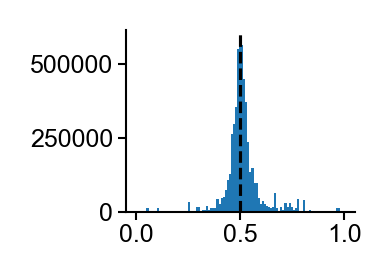

In [124]:
plt.figure(figsize=array2inch(2.5, 2))
plt.hist(per_variant_results['es_combined'], bins=101, lw=0, range=(0, 1))
plt.axvline(x=0.5, ls='--', color='k')
plt.show()

<Axes: xlabel='p_differential', ylabel='Count'>

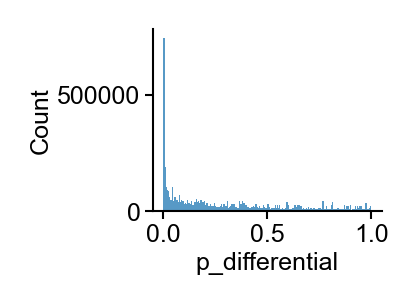

In [125]:
plt.figure(figsize=array2inch(2.5, 2))
sns.histplot(per_variant_results['p_differential'], lw=0)

### categories

In [126]:
per_variant_results['category'].value_counts()

category
not_imbalanced            6612640
not_cell_selective        1781031
concordant_and_overall     369951
discordant                 246203
discordant_and_overall     227342
concordant                  83326
weak_cell_selective           139
Name: count, dtype: int64

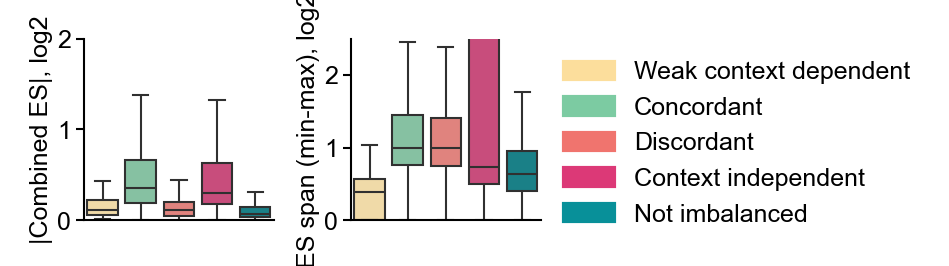

In [127]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=array2inch(5, 2))
plt.subplots_adjust(wspace=0.4)
order = per_variant_results['core_category'].cat.categories

legend_handles = [mpatches.Patch(color=category_colors[x]) for x in order]

sns.boxplot(showfliers=False, ax=ax1, legend=False, 
            data=per_variant_results, 
            x='core_category', hue='core_category', order=order,
            y=per_variant_results['logit_es_combined'].abs(), palette=category_colors,
           linewidth=0.5)
ax1.set_xticklabels([])
ax1.set_ylabel('|Combined ES|, log2')
ax1.set_xlabel('')
ax1.set_xticks([])
ax1.set_ylim(0, 2)

sns.boxplot(showfliers=False, ax=ax2, data=per_variant_results, order=order,
            x='core_category', hue='core_category', 
            y=per_variant_results['delta_logit_es'].abs(), palette=category_colors,
           linewidth=0.5)
ax2.legend(legend_handles, [category_labels[x] for x in order], title='', bbox_to_anchor=(1,1), loc='upper left',)
ax2.set_xticklabels([])
ax2.set_ylabel('ES span (min-max), log2')
ax2.set_xlabel('')
ax2.set_xticks([])
ax2.set_ylim(0, 2.5)
plt.show()

In [195]:
# Cell-selective variants pie chart

In [128]:
overall_imbalanced_cats = ['not_cell_selective', 'concordant_and_overall', 'discordant_and_overall']
cell_selective_cats = ['concordant_and_overall', 'discordant_and_overall', 'discordant', 'concordant',  'weak_cell_selective']

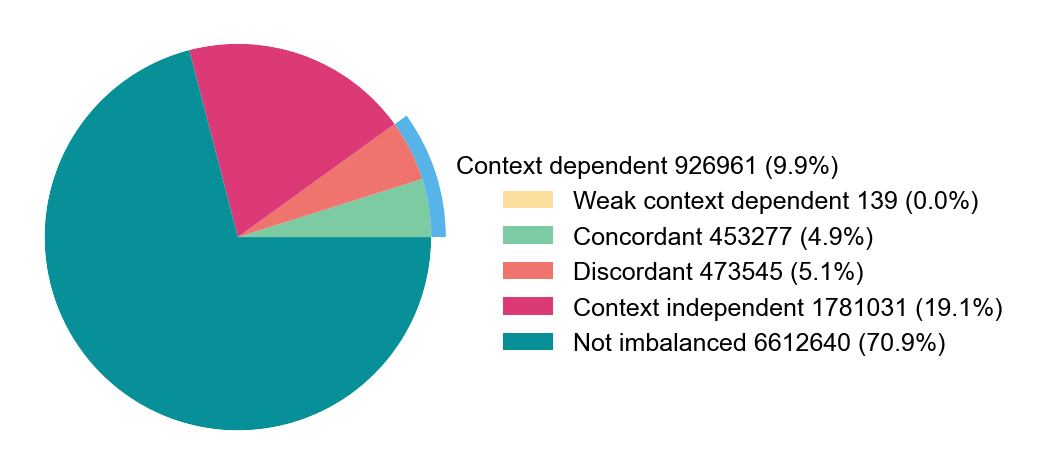

In [129]:
# ===============================
# Pie chart from per-variant AnnData.var
# ===============================

# Helper: percentage
def fm(x, total):
    return 0 if total == 0 else 100 * x / total


# One row = one variant → total variants
total_count = len(per_variant_results)


# Visual parameters
size = 0.07
scale = 1.5


# -------------------------------
# Count variants per category
# -------------------------------
category_counts = (
    per_variant_results
    .groupby("core_category")
    .size()
    .reset_index(name="variant_id")
    .sort_values("core_category")
    .reset_index(drop=True)
)

category_counts["percentage"] = category_counts["variant_id"].apply(
    lambda x: fm(x, total_count)
)


# -------------------------------
# Broad selective vs non-selective ring
# -------------------------------
category_counts["selective"] = category_counts["core_category"].isin(cell_selective_cats)

# group consecutive True/False segments
category_counts["selective_gr"] = (
    category_counts["selective"] != category_counts["selective"].shift()
).cumsum()

selective = (
    category_counts
    .groupby(["selective_gr", "selective"], as_index=False)
    [["variant_id", "percentage"]]
    .sum()
    .drop(columns="selective_gr")
)


# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(1.5, 1.5))

# Inner ring: fine-grained categories
patches_inner, _ = plt.pie(
    category_counts["variant_id"],
    radius=scale * (1 - size),
    wedgeprops={"linewidth": 0, "width": scale * (1 - size)},
    colors=[category_colors[x] for x in category_counts["core_category"]],
)

# Outer ring: selective vs non-selective
patches_outer, _ = plt.pie(
    selective["variant_id"],
    radius=scale,
    wedgeprops={"linewidth": 0, "width": scale * size, "edgecolor": "none"},
    colors=["#56B4E9" if x else "#FFFFFF" for x in selective["selective"]],
    labels=[
        f"Context dependent {row.variant_id} ({row.percentage:.1f}%)"
        if row.selective else ""
        for _, row in selective.iterrows()
    ],
)

# Ensure no borders
for p in patches_outer:
    p.set_edgecolor("none")
    p.set_linewidth(0)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)


# -------------------------------
# Legend
# -------------------------------
plt.legend(
    patches_inner,
    [
        f"{category_labels[row.core_category]} "
        f"{row.variant_id} ({row.percentage:.1f}%)"
        for _, row in category_counts.iterrows()
    ],
    bbox_to_anchor=(1.2, 0.7),
    frameon=False,
)

plt.show()

In [130]:
### plot

In [131]:
import logging
import warnings
import numpy as np
import pandas as pd
import h5py
import os

from typing import Sequence, Union
from matplotlib import gridspec
from matplotlib import transforms
import seaborn as sns
import matplotlib.pyplot as plt

In [132]:
class LoggerMixin:
    def __init__(self, logger_level: int = logging.INFO):
        self.logger = logging.getLogger(self.__class__.__name__)
        self.logger.setLevel(logger_level)

In [133]:
class PlotComponent(LoggerMixin):
    def __init__(
        self,
        width: float = 1.0,
        margins: Union[float, Sequence[float]] = 0.1,
        names_to_colors: dict = None,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.width = width
        self.names_to_colors = names_to_colors

        if isinstance(margins, Sequence) and not isinstance(margins, str):
            if len(margins) != 2:
                raise ValueError("margins must be length 2")
            self.margin_left, self.margin_right = margins
        else:
            self.margin_left = self.margin_right = margins

    def plot(self, data, gs, fig, **kwargs):
        raise NotImplementedError

In [134]:
short_to_full_group_name = {
    'ALL': 'Adult tissues (Mixed)',
    'AML': 'Myeloid (CMP)',
    'APL': 'Myeloid (Erythroid)',
    'Adipose': 'Adult tissues (Heart/Muscle/Stromal)',
    'Adrenal': 'Endocrine (Adrenal)',
    'Astrocyte': 'Nervous (Fetal CNS/Eye)',
    'B-cell': 'Lymphoid (B-cells)',
    'Bladder': 'Epithelial',
    'Brain stem': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Bone': 'Adult tissues (Mixed)',
    'Bone marrow': 'Myeloid (CMP)',
    'CMP': 'Myeloid (CMP)',
    'CML': 'Myeloid (Erythroid/CMP)',
    'Carcinoma': 'Epithelial',
    'Cerebellum': 'Nervous (Cerebellum)',
    'Fetal life support': 'Fetal life supprot (Trophoblasts)',
    'Cerebral cortex': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Colon': 'Gastrointestinal (Adult Intestine)',
    'Dendritic': 'Myeloid (Macrophage) A',
    'Endothelium': 'Endothelial',
    'Epithelium': 'Epithelial',
    'Erythroid': 'Myeloid (Erythroid)',
    'Eye': 'Nervous (Fetal CNS/Eye)',
    'Hepatic': 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)',
    'Fibroblast': 'Stromal (Skin fibroblasts)',
    'Gallbladder': 'Gastrointestinal (Adult Intestine)',
    'Heart': 'Adult tissues (Heart/Muscle/Stromal)',
    'Limbic system': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Intestine': 'Gastrointestinal (Adult Intestine)',
    'Lung': 'Respiratory (Fetal)',
    'Liposarcoma': 'Adult tissues (Mixed)',
    'Pancreas': 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)',
    'Plasmacytoma': 'Myeloid (Erythroid/CMP)',
    'Lymphoma': 'Lymphoid (B-lymphoblasts)',
    'Macrophage': 'Myeloid (Macrophage) B',
    'Mammary adenocarcinoma': 'Epithelial',
    'Mammary ductal carcinoma': 'Epithelial',
    'Melanocyte': 'Epithelial',
    'Monocyte': 'Myeloid (Monocyte)',
    'Muscle': 'Adult tissues (Heart/Muscle/Stromal)',
    'Myeloma': 'Myeloid (Erythroid/CMP)',
    'Myoblast': 'Skeletal muscle (Fetal)',
    'Myocyte': 'Skeletal muscle (Fetal)',
    'NK-cell': 'Lymphoid (NK-cells)',
    'Nerve': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Non-SCLC': 'Lung',
    'Ovary': 'Ovary/Uterus',
    'Stroma': 'Stromal/Epithelial',
    'T-cell': 'Lymphoid (Activated T-cells)',
    'Pluripotent/Pluripotent-derived': 'Pluripotent/Pluripotent-derived',
    'Prostate': 'Epithelial',
    'Rhaboid tumor': 'Adult tissues (Mixed)',
    'SCLC': 'Lung',
    'Sarcoma': 'Adult tissues (Mixed)',
    'Spinal cord': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Uterus': 'Ovary/Uterus',
    'Ureter': 'Renal (Fetal)',
    'Testis': 'Endocrine (Adrenal)',
    'Thyroid': 'Endocrine (Thyroid)',
    'Basal ganglia': 'Nervous (Basal ganglia)',
    'Kidney': 'Epithelial (Kidney)',
    'Stomach': 'Gastrointestinal (Stomach)'
}

In [181]:
from genome_tools import GenomicInterval

In [182]:
import numpy as np
import pandas as pd
from typing import Sequence

class AnnDataVariantPreprocessor(LoggerMixin):
    """
    Preprocessor that extracts per-variant data directly from an AnnData object.
    Uses layers like 'logit_es.epoch_1', 'ref_counts.epoch_1', etc., 
    and obs/var for sample and variant info.
    """
    def __init__(self, adata, suffix="epoch_1", **kwargs):
        super().__init__(**kwargs)
        self.adata = adata
        self.suffix = suffix
    
    def filter_dfs(self, tested_df, anova_df, groups, coverage_tr):
        if groups is not None:
            anova_df = anova_df[anova_df['group_name'].isin(groups)]
            tested_df = tested_df[tested_df['group_name'].isin(groups)]

        if coverage_tr > 0:
            tested_df = tested_df.query(f'(ref_counts + alt_counts) >= {coverage_tr}')
            anova_df = anova_df[anova_df['group_name'].isin(tested_df['group_name'])]


        if tested_df.empty or anova_df.empty:
            self.logger.error(f'No data left after filtering with groups {groups} and coverage threshold {coverage_tr}')
        return tested_df, anova_df
    
    def ann_to_df(self, adata_var, suffix="epoch_1"):
        df = pd.DataFrame({
            "sample_id": adata_var.obs_names.values,
            "group_id": adata_var.obs["extended_annotation"].values,
            "variant_id": adata_var.var_names[0],
            "#chr": adata_var.var["#chr"].values[0],
            "start": adata_var.var["start"].values[0],
            "end": adata_var.var["end"].values[0],
            "ref": adata_var.var["ref"].values[0],
            "alt": adata_var.var["alt"].values[0],
            "ID": adata_var.var["ID"].values[0],
            "category":adata_var.var["category"].values[0]
        })
    
        for layer_name in adata_var.layers.keys():
            vals = adata_var.layers[layer_name]
    
            # convert sparse safely
            if sp.issparse(vals):
                vals = vals.toarray().ravel()
            else:
                vals = vals.ravel()
    
            # remove suffix (e.g. ".epoch_1")
            if layer_name.endswith(f".{suffix}"):
                clean_name = layer_name.replace(f".{suffix}", "")
            else:
                clean_name = layer_name
    
            df[clean_name] = vals
    
        return df

    def get_variant_data(self,
                         variant_id: str,
                         components: Sequence[PlotComponent],
                         sort_eval: str = 'group_es',
                         groups: list = None,
                         coverage_tr: int = 0):
        """
        Extract per-sample and per-group data for a single variant.
        Returns: components, component_data, n_samples
        """
        
        # --- Find the variant column(s) in .var ---
        var_inds = np.where(self.adata.var["ID"].values == variant_id)[0]
        if len(var_inds) == 0:
            self.logger.error(f"Variant {variant_id} not found in .var")
            return [], [], 0

        # --- Subset the AnnData to only this variant ---
        adata_var = self.adata[:, var_inds].copy()
        
        tested_df = self.ann_to_df(adata_var)

        # Add human-readable group name
        tested_df['group_name'] = tested_df['group_id'].map(short_to_full_group_name)
        
        # Optional: filter by groups/coverage
        tested_df, anova_df = self.filter_dfs(tested_df, tested_df, groups, coverage_tr)
        
        # Sort by the evaluation metric
        anova_df = anova_df.iloc[anova_df.eval(sort_eval).argsort()]

        self.logger.debug(anova_df[['z', 'group_es_var', 'group_es_std', 'full_group_std', 'group_es']])

        self.logger.debug(anova_df['category'].values[0])
        self.logger.debug(anova_df['variant_id'].values[0])
        self.logger.debug(anova_df['ID'].values[0])
        self.logger.debug('Delta ES q', anova_df['delta_es_q'].values[0])
        self.logger.debug('Discordance score', anova_df['discordance_score'].values[0])
        self.logger.debug('Diff P-value', anova_df['p_differential'].values[0])


        # --- Generate component data for plotting ---
        component_data = []
        for component in components:
            if isinstance(component, DensityPlotComponent):
                dens, interval = self.get_density(tested_df,adata_var)
                data = anova_df, dens, interval
            elif isinstance(component, ImbalancePlotComponent):
                data = tested_df, anova_df
            elif isinstance(component, PredictionPlotComponent):
                data = anova_df
            elif isinstance(component, ContributionPlotComponent):
                X, all_scores = self.get_shap_scores(anova_df)
                data = anova_df, X, all_scores
            else:
                self.logger.error(f"Unsupported component type: {type(component)}")
                raise ValueError(f"Unsupported component type: {type(component)}")
            component_data.append(data)

        return components, component_data, len(tested_df)

    def get_density(self, tested_df, adata_var):
        """
        Compute average density per group directly from normalized_density_bw in adata_var.obs.
        
        Args:
            tested_df: DataFrame of per-sample variant data
            adata_var: AnnData object subset to this variant
        
        Returns:
            dens: dict[group_name] -> np.array of densities
            interval: genomic_interval object for the region
        """
        dens = {}
    
        # Map sample_id in tested_df to .obs
        obs_df = adata_var.obs
    
        for group_name, df_group in tested_df.groupby("group_name"):
            # Pull the normalized density bw files from obs
            density_files = obs_df.loc[df_group['sample_id'], 'normalized_density_bw']
    
            # If all NaN, fallback to zeros
            if density_files.isna().all():
                width = df_group["end"].iloc[0] - df_group["start"].iloc[0]
                dens[group_name] = np.zeros(width, dtype=np.float_)
                continue
    
            # Keep only valid paths
            density_files = density_files.dropna().tolist()
    
            chrom = df_group["#chr"].iloc[0]
            start = df_group["start"].iloc[0]
            end = df_group["end"].iloc[0]
    
            # Create interval, widen by 2000 as before
            interval = GenomicInterval(chrom, start, end).widen(2000)
    
            # Extract densities from all files
            all_dens = []
            for f in density_files:
                bw = bigwig_extractor(f)
                all_dens.append(bw[interval])
    
            # Weighted average by inverse_mse
            weights = df_group.loc[df_group['sample_id'].isin(density_files), 'inverse_mse']
            dens[group_name] = np.average(np.array(all_dens), axis=0, weights=weights)
    
        return dens, interval

    def get_shap_scores(self, anova_df):
        """
        Placeholder to return SHAP contributions per group.
        """
        X = [None]*len(anova_df)
        all_scores = [None]*len(anova_df)
        return X, all_scores

In [183]:
# --------------------------------------- Plotting ---------------------------------------
    

class ImbalancePlotComponent(PlotComponent):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def plot(self, data, gs, fig):
        tested_df, anova_df = data
        ref_allele, alt_allele, rsid = anova_df['ref'].values[0], anova_df['alt'].values[0], anova_df['ID'].values[0]
        ax = fig.add_subplot(gs)
        sns.stripplot(data=tested_df, y='group_name', x='logit_es', order=anova_df['group_name'], ax=ax, s=5, zorder=-1, orient='h',
                 palette=self.names_to_colors, alpha=0.3)
        
        ax.errorbar(x=anova_df['logit_group_es'], y=anova_df['group_name'], xerr=anova_df['logit_group_es_std'], fmt='.', capsize=4, capthick=1.0, c='k', lw=1.0)
        ax.scatter(y=anova_df['group_name'], x=anova_df['logit_group_es'], lw=3, ec=anova_df['group_name'].map(self.names_to_colors).values, color='k', s=12)
        ax.set_yticklabels([x.get_text().replace(' (', '\n(').replace('/', '/\n') for x in ax.get_yticklabels()])

        trans = transforms.blended_transform_factory(ax.transAxes, ax.transAxes)
        
        ax.annotate(alt_allele, xy=(0.1, 1.05), xycoords=trans, fontname="IBM Plex Mono", fontweight="bold", fontsize=7, bbox=dict(boxstyle="Circle", ec='none', fc=cm.map_vocab_color(alt_allele, 'dna')[0]))
        ax.annotate(ref_allele, xy=(0.9, 1.05), xycoords=trans, fontname="IBM Plex Mono", fontweight="bold", fontsize=7, bbox=dict(boxstyle="Circle", ec='none', fc=cm.map_vocab_color(ref_allele, 'dna')[0]))

        for i in range(len(anova_df['group_name']) - 1):
            ax.axhline(i + 0.5, ls='--', color='k', lw=0.5)


        #---------------------------------------
        # asterisks
        minx, maxx = (min(-0.1, tested_df['logit_es'].min(), (anova_df['logit_group_es'] - anova_df['logit_group_es_std']).min()), max(0.1, tested_df['logit_es'].max(), (anova_df['logit_group_es'] + anova_df['logit_group_es_std']).max()))
        val = max(np.abs(x) for x in [minx, maxx]) * 1.1
        # val = min(5.0, val)

        for i, (_ , row) in enumerate(anova_df.iterrows()):
            if row['fdr_group'] <= 0.1: ## Asterisk criterion  <--------
                if row['logit_group_es'] > 0:
                    asterisk_x = (row['logit_group_es'] + row['logit_group_es_std']) + val * 0.1
                else:
                    asterisk_x = (row['logit_group_es'] - row['logit_group_es_std']) - val * 0.1

                ax.text(s='*', x=asterisk_x, y=i+0.15, fontdict={'size': 20, 'color': 'red'}, ha='center', va='center')

        ax.set_ylim(len(anova_df['group_name']) - 1 + 0.5, -0.5)

        ax.set_yticks([x - 0.125 for x in ax.get_yticks()], )
        ax.tick_params('x', length=3, width=0.75, which='major')
        ax.tick_params('y', length=0, width=0, which='major')

        ax.spines['left'].set_linewidth(0.75)
        ax.spines['bottom'].set_linewidth(0.75)
        
        ax.axvline(0, ls='--', color='k', lw=0.5)
        ax.axvspan(-0.5, 0.5, color='grey', alpha=0.1, lw=0)
        
        ax.set_xlabel("Variant effect size (log2 ref/alt)")
        ax.set_ylabel("")

        ax.set_xlim(-val*1.3, val*1.3)
        ax.set_title(rsid)

        return ax


class DensityPlotComponent(PlotComponent):
    def __init__(self, common_norm=True, clip_max=None, clip_min=0, common_norm_quantile=1.0, **kwargs):
        super().__init__(**kwargs)
        self.common_norm = common_norm # wether to set a common y scale for all density plots
        self.common_norm_quantile = common_norm_quantile # quantile of max y values across rows to use as ylim
        self.clip_max = clip_max # hard threshold that ylim can not exceed
        self.clip_min = clip_min # hard threshold that ylim can not be lower than
        

    def plot(self, data, gs, fig):
        anova_df, dens, interval = data
        ref_allele = anova_df['ref'].values[0]
        alt_allele = anova_df['alt'].values[0]
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, gs, hspace=0)
        axes = []

        for i, group_name in enumerate(anova_df['group_name']):
            ax = fig.add_subplot(gs_subplot[i, :])
            signal_plot(interval, dens[group_name], color=self.names_to_colors[group_name], ax=ax)
            
            if i == len(anova_df)-1:
                ax.xaxis.set_visible(True)
                ax.set_xlabel(f"{anova_df['#chr'].values[0]}")
                ax.tick_params('x', length=3, width=0.7, which='major')
            else:
                ax.xaxis.set_visible(False)

            max_dens_value = np.nanmax(dens[group_name])
        
            if i == 0:
                ax.annotate(xy=((interval.end+interval.start)//2, max_dens_value), ha='center', text=f"{ref_allele}/{alt_allele}", xytext=(0, 25), textcoords="offset points", arrowprops=dict(arrowstyle="->"))

            ax.set_yticks([])
            ax.spines['left'].set_linewidth(0.75)
            ax.spines['bottom'].set_linewidth(0.75)
            pos = ax.get_position()
            ax.set_ylim(0, np.clip(max_dens_value, self.clip_min, self.clip_max))
            ax.set_position([pos.x0, pos.y0, pos.width, pos.height * 0.8])
            axes.append(ax)

        if self.common_norm:
            top = np.nanquantile([np.nanmax(d) for d in dens.values()], self.common_norm_quantile)
            top = np.clip(top, self.clip_min, self.clip_max)
            for ax in axes:
                ax.set_ylim(0, top)
        
        common_ax = fig.add_subplot(gs)
        common_ax.axvline(0.5, ls='--', color='k', lw=0.5)
        common_ax.axis('off')
        common_ax.annotate(xy=(-0.1, 0.5), ha='center', va='center', rotation=90, text='DNase I density', annotation_clip=False)
        return axes, common_ax

In [184]:
metadata = meta.rename(columns={'extended_annotation':'cluster_name'})

In [185]:
meta

,sample_id,extended_annotation
0,AG10028,CML
1,AG10029,CML
2,AG10031,CML
3,AG10032,CML
4,AG10033,CML
...,...,...
3475,AG70923,Monocyte
3476,AG72731,Fetal life support
3477,AG4026,Colon
3478,AG4009,Thyroid


In [186]:
names_to_colors = get_palette_dict(metadata['cluster_name'].dropna())


In [187]:
components = [
    DensityPlotComponent(names_to_colors=names_to_colors, width=2),
    ImbalancePlotComponent(names_to_colors=names_to_colors, width=2),
]

In [188]:
preprocessor = AnnDataVariantPreprocessor(train_var_adata, suffix="epoch_1")

In [189]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 757925
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 't

In [190]:

def setup_gridspec(plot_components):
    """
    Setup the gridspec for the plots.
    Components are plotted in the middle column, with margins on the left and right.
    """
    width_ratios = [
        x
        for c in plot_components
        for x in [c.margin_left, c.width, c.margin_right]
    ]
    return gridspec.GridSpec(1, len(width_ratios), width_ratios=width_ratios, wspace=0, hspace=0)


def plot_variant(data,
                 fig=None,
                 group_height=0.4,
                 inches_per_unit=1.0
                ):
    plot_components, variant_data, num_groups = data
    
    if fig is None:
        fig = plt.figure(figsize=(
            sum(x for c in plot_components for x in [c.margin_left, c.width, c.margin_right]) * inches_per_unit,
            num_groups * group_height * inches_per_unit))
    
    component_axes = []

    master_gs = setup_gridspec(plot_components)
    for i, (component, component_data) in enumerate(zip(plot_components, variant_data)):
        component_axes.append(component.plot(component_data, gs=master_gs[:, 3*i + 1], fig=fig))
    
    return component_axes, master_gs

In [192]:
from genome_tools.data.extractors import BigwigExtractor as bigwig_extractor 

In [193]:
variant_id = "rs10151094"
data = preprocessor.get_variant_data(
    variant_id=variant_id,
    components=components
)

ValueError: Shape of weights must be consistent with shape of a along specified axis.

In [ ]:
from genome_tools.plotting import signal_plot


In [ ]:
axes, gs = plot_variant(data)
axes[1].set_xlim(-4, 4)

['ALL', 'AML', 'APL', 'Adipose', 'Adrenal', 'Astrocyte', 'B-cell', 'Bladder', 'Brain stem', 'Blastoma', 'Bone', 'Bone marrow', 'CMP', 'CML', 'Carcinoma', 'Cerebellum', 'Fetal life support', 'Cerebral cortex', 'Colon', 'Dendritic', 'Endothelium', 'Epithelium', 'Erythroid', 'Eye', 'Hepatic', 'Fibroblast', 'Gallbladder', 'Heart', 'Limbic system', 'Intestine', 'Lung', 'Liposarcoma', 'Pancreas', 'Plasmacytoma', 'Lymphoma', 'Macrophage', 'Mammary adenocarcinoma', 'Mammary ductal carcinoma', 'Melanocyte', 'Monocyte', 'Muscle', 'Myeloma', 'Myoblast', 'Myocyte', 'NK-cell', 'Nerve', 'Non-SCLC', 'Ovary', 'Stroma', 'T-cell', 'Pluripotent/Pluripotent-derived', 'Prostate', 'Rhaboid tumor', 'SCLC', 'Sarcoma', 'Spinal cord', 'Uterus', 'Ureter', 'Testis', 'Thyroid', 'Basal ganglia', 'Kidney', 'Stomach']
